<a href="https://colab.research.google.com/github/andrelbarbosas/CP01Python/blob/main/CHECKPOINT_1_Machine_Learning_%26_Statistical_Computing_(2%C2%BA_Semestre).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**CHECKPOINT 1 - Machine Learning & Statistical Computing**

**Turma:** 1TIAPR-2025 (2º Semestre)

**Data de Entrega:** 09/04/2026

**Integrantes do Grupo**
* **André Barbosa** – RM: 568145
* **Ciro Yamauchi** – RM: 566933
* **Roberto Oliveira** – RM: 567239

### **Informações do Projeto**
* **Disciplinas Integradas:** Machine Learning & Modelling e Statistical Computing
* **Professores:** Rodolfo (Statistical Computing) e Mário (Machine Learning)
* **Dataset Utilizado:** Case Ifood

---

### **Resumo das Etapas Realizadas**

1.  **Parte 1:** Aplicação do Teste Z para comparação de médias entre os grupos Response 0 e 1 ($\alpha=0.05$).
2.  **Parte 2:** Desenvolvimento de modelo preditivo com Random Forest, utilizando Feature Engineering e métricas de classificação.
3.  **Parte 3:** Análise comparativa entre as features estatisticamente significativas e a importância de variáveis no modelo de ML.

In [152]:
#Bibliotecas

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#2. Carregar arquivo CSV

In [153]:
#Carregar dataset (Guardei o dataset na variável df )
df = pd.read_csv('data.csv')

print('Arquivo carregado!')
print(f'Linhas: {df.shape[0]}')
print(f'Colunas: {df.shape[1]}')

Arquivo carregado!
Linhas: 2240
Colunas: 29


#3. Dar uma olhada nos dados

In [154]:
#Vizualizar primeiras linhas
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,0,0,0,0,0,0,3,11,0


In [155]:
#Vizulizar tipo de dados
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [156]:
#Estatisiticas basicas
df.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,...,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,...,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


In [157]:
#Verificar quantos clientes responderam a campanha
df['Response'].value_counts()

# Response é nossa variável alvo: 1 = aceitou a oferta, 0 = não aceitou

,count
Response,
0,1906
1,334


#4. Limpeza dos Dados

Elimiei as variaveis Z_CostContact e Z_Revenue têm o mesmo valor em todas as linhas
(3 e 11 respectivamente) — não trazem nenhuma informação útil
ID é só um número de identificação, não é uma característica do cliente

In [158]:
#Excluir colunas sem valor significativo

df = df.drop(columns=['ID', 'Z_CostContact', 'Z_Revenue'])

print(f'Colunas agora: {df.shape[1]}')



Colunas agora: 26


In [159]:
# Verificar quantos valores vazios existem na Variavel 'Income'
print('Valores vazios em Income:', df['Income'].isnull().sum())

Valores vazios em Income: 24


In [160]:
# Preenchi com a mediana (o valor do meio quando ordenamos todos os salários)usei a mediana e não média porque a média é afetada por salários muito altos ou muito baixos

mediana_income = df['Income'].median()
df['Income'] = df['Income'].fillna(mediana_income)

print('Valores vazios depois do preenchimento:', df['Income'].isnull().sum())

Valores vazios depois do preenchimento: 0


Corrigir idades absurdas observadas em 'Year_Bearth' Ex: min = 1893

In [161]:
# Validar quais anos de nascimento existem no dataset
print('Menor ano de nascimento:', df['Year_Birth'].min())
print('Maior ano de nascimento:', df['Year_Birth'].max())

# Remover quem teria mais de 90 anos (muito provavelmente erro de digitação)
df = df[df['Year_Birth'] >= 1935]

print(f'Linhas após limpeza: {len(df)}')

Menor ano de nascimento: 1893
Maior ano de nascimento: 1996
Linhas após limpeza: 2237


In [162]:
#Validar a quanto tempo são clientes.
print('Cliente mais antigo:', df['Dt_Customer'].min())
print('Cliente mais recente:', df['Dt_Customer'].max())


Cliente mais antigo: 2012-07-30
Cliente mais recente: 2014-06-29


#5. Feature engineering

Transformar dados brutos em informações mais úteis para o modelo.

In [163]:
# CCalculei idade de cada cliente. É mais intuitivo trabalhar com Idade do que com Ano de Nascimento
df['Age'] = 2025 - df['Year_Birth']

print('Idade mínima:', df['Age'].min())
print('Idade máxima:', df['Age'].max())
print('Idade média: ', df['Age'].mean().round(1))

Idade mínima: 29
Idade máxima: 85
Idade média:  56.1


In [164]:
# Transformei Dt_Customer em idade de cadastro para saber há quantos anos o cliente é cliente.

df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'])
df['Year_Customer'] = 2025 - df['Dt_Customer'].dt.year

print('Há quantos anos são clientes')
print('Idade min cadastro:', df['Year_Customer'].min())
print('Idade max cadastro:', df['Year_Customer'].max())
print('Idade média cadastro: ', df['Year_Customer'].mean().round(1))

Há quantos anos são clientes
Idade min cadastro: 11
Idade max cadastro: 13
Idade média cadastro:  12.0


In [165]:
#Calculei o gasto total de cada cliente. O dataset tem o gasto separado por categoria (vinho, carne, peixe...).  Somei tudo para ter o gasto total

df['TotalSpend'] = (df['MntWines'] +
                    df['MntFruits'] +
                    df['MntMeatProducts'] +
                    df['MntFishProducts'] +
                    df['MntSweetProducts'] +
                    df['MntGoldProds'])

print('Gasto médio por cliente: R$', df['TotalSpend'].mean().round(2))

Gasto médio por cliente: R$ 605.74


In [166]:
print('Resumo do dataset limpo')
print(f'Linhas  : {df.shape[0]}')
print(f'Colunas : {df.shape[1]}')
print(f'Valores vazios: {df.isnull().sum().sum()}')

Resumo do dataset limpo
Linhas  : 2237
Colunas : 29
Valores vazios: 0


In [167]:
#Salvei em um novo arquivo para não perder o original

df.to_csv('ifood_limpo.csv', index=False)

print('Arquivo salvo: ifood_limpo.csv')

Arquivo salvo: ifood_limpo.csv


#Teste Z

#1. Carregar o dataset limpo e importar o ztest

In [168]:
from statsmodels.stats.weightstats import ztest

df = pd.read_csv('ifood_limpo.csv')

print('Pronto! Linhas:', len(df))
print('Colunas:', len(df.columns))

Pronto! Linhas: 2237
Colunas: 29


In [169]:
#Validei as novas variaveis (Age, Year_Custumer, TotalSpend)
df.head()

,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,...,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,Age,Year_Customer,TotalSpend
0,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,88,...,0,0,0,0,0,0,1,68,13,1617
1,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,1,...,0,0,0,0,0,0,0,71,11,27
2,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,49,...,0,0,0,0,0,0,0,60,12,776
3,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,4,...,0,0,0,0,0,0,0,41,11,53
4,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,43,...,0,0,0,0,0,0,0,44,11,422


Separar 'Response' em dois grupos 0 e 1

In [170]:
# Grupo dos clientes que NÃO aceitaram a campanha
grupo_0 = df[df['Response'] == 0]

# Grupo dos clientes que ACEITARAM a campanha
grupo_1 = df[df['Response'] == 1]

print('Grupo 0 (não aceitou):', len(grupo_0), 'clientes')
print('Grupo 1 (aceitou)    :', len(grupo_1), 'clientes')

Grupo 0 (não aceitou): 1903 clientes
Grupo 1 (aceitou)    : 334 clientes


Para cada feature numérica, vamos perguntar: "a média dessa feature é diferente entre esses dois grupos?"

In [171]:
# Vou fazer o teste só com Income primeiro, para entender o resultado

z_stat, p_valor = ztest(grupo_0['Income'], grupo_1['Income'])

print(f'Média Income — grupo 0: {grupo_0["Income"].mean():.2f}')
print(f'Média Income — grupo 1: {grupo_1["Income"].mean():.2f}')
print(f'p-value: {p_valor:.4f}')

if p_valor < 0.05:
    print('→ Diferença SIGNIFICATIVA (p < 0.05)')
else:
    print('→ Diferença NÃO significativa (p >= 0.05)')

Média Income — grupo 0: 50831.06
Média Income — grupo 1: 60183.24
p-value: 0.0000
→ Diferença SIGNIFICATIVA (p < 0.05)


In [172]:
#Agora selecionei somente as colunas numéricas. Vou excluir 'Response' porque ela é nossa variavel alvi, não uma feature.

colunas_numericas = df.select_dtypes(include='number').columns.tolist()
colunas_numericas.remove('Response')

print(f'Total de features para testar: {len(colunas_numericas)}')
print(colunas_numericas)

Total de features para testar: 25
['Year_Birth', 'Income', 'Kidhome', 'Teenhome', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Complain', 'Age', 'Year_Customer', 'TotalSpend']


In [173]:
#Aplicação do Ztest em todas as colunas

# Listar resultados
resultados = []

# Para cada coluna numérica, rodei o ztest e guardei o resultado
for coluna in colunas_numericas:
    z, p = ztest(grupo_0[coluna], grupo_1[coluna])

    resultados.append({
        'feature'       : coluna,
        'media_grupo_0' : grupo_0[coluna].mean().round(2),
        'media_grupo_1' : grupo_1[coluna].mean().round(2),
        'p_value'       : round(p, 4),
        'significativa' : p < 0.05
    })

# Transformei a lista em uma tabela e ordenada pelo p-value
df_resultados = pd.DataFrame(resultados).sort_values('p_value')

df_resultados

,feature,media_grupo_0,media_grupo_1,p_value,significativa
1,Income,50831.06,60183.24,0.0000,True
3,Teenhome,0.54,0.31,0.0000,True
5,MntWines,269.12,502.70,0.0000,True
4,Recency,51.51,35.38,0.0000,True
6,MntFruits,24.18,38.20,0.0000,True
7,MntMeatProducts,144.55,294.35,0.0000,True
9,MntSweetProducts,25.04,38.63,0.0000,True
8,MntFishProducts,34.97,52.05,0.0000,True
13,NumCatalogPurchases,2.39,4.20,0.0000,True
12,NumWebPurchases,3.91,5.07,0.0000,True


In [174]:
# Filtrei somente as linhas onde significativa == True
sig = df_resultados[df_resultados['significativa'] == True]

print(f'{len(sig)} features com diferença significativa entre os grupos:')
print(sig[['feature', 'media_grupo_0', 'media_grupo_1', 'p_value']].to_string(index=False))

19 features com diferença significativa entre os grupos:
            feature  media_grupo_0  media_grupo_1  p_value
             Income       50831.06       60183.24   0.0000
           Teenhome           0.54           0.31   0.0000
           MntWines         269.12         502.70   0.0000
            Recency          51.51          35.38   0.0000
          MntFruits          24.18          38.20   0.0000
    MntMeatProducts         144.55         294.35   0.0000
   MntSweetProducts          25.04          38.63   0.0000
    MntFishProducts          34.97          52.05   0.0000
NumCatalogPurchases           2.39           4.20   0.0000
    NumWebPurchases           3.91           5.07   0.0000
       MntGoldProds          40.90          61.45   0.0000
       AcceptedCmp2           0.01           0.06   0.0000
       AcceptedCmp1           0.03           0.24   0.0000
       AcceptedCmp5           0.04           0.28   0.0000
       AcceptedCmp4           0.06           0.19   0.0000

/tmp/ipykernel_44688/1062581404.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_44688/1062581404.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_44688/1062581404.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_44688/1062581404.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_44688/1062581404.py:9: FutureWarning: 

P

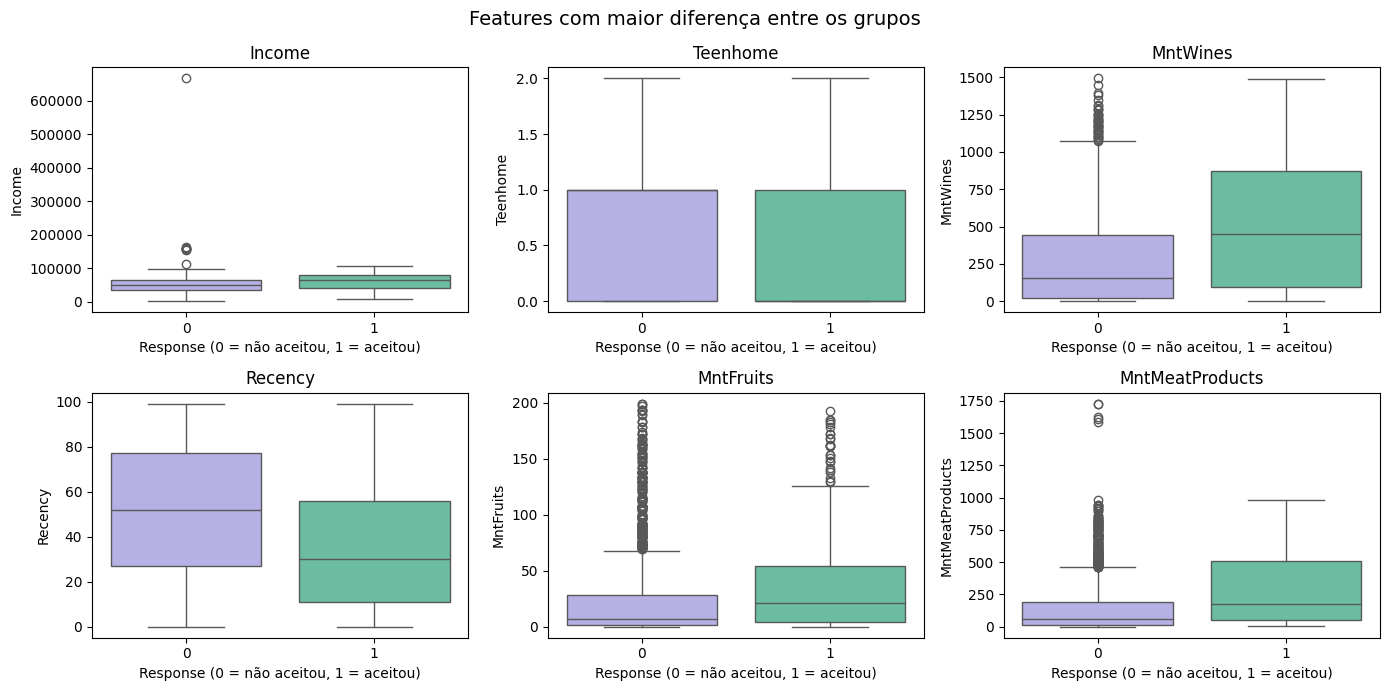

In [175]:
# Peguei as 6 features com menor p-value (as mais diferentes entre os grupos)
top6 = sig.head(6)['feature'].tolist()

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.flatten()

for i, feat in enumerate(top6):
    # Para cada feature, desenhamos um boxplot comparando os dois grupos
    sns.boxplot(
        data=df,
        x='Response',
        y=feat,
        ax=axes[i],
        palette=['#AFA9EC', '#5DCAA5']
    )
    axes[i].set_title(feat, fontsize=12)
    axes[i].set_xlabel('Response (0 = não aceitou, 1 = aceitou)')

plt.suptitle('Features com maior diferença entre os grupos', fontsize=14)
plt.tight_layout()
plt.show()

In [176]:
# Salvar a tabela completa de resultados em um CSV

# Vamos precisar dela na Parte 3 para comparar com o modelo de ML
df_resultados.to_csv('resultados_teste_z.csv', index=False)

print('Arquivo salvo: resultados_teste_z.csv')

Arquivo salvo: resultados_teste_z.csv


#Machine Learning

Vamos treinar um modelo que aprende com os dados históricos e passa a prever se um cliente vai aceitar ou não uma campanha.

Carregar dataset com os dados limpos e preparar as colunas categóricas

In [177]:

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, roc_auc_score

df = pd.read_csv('ifood_limpo.csv')

print('Dataset carregado! Shape:', df.shape)

Dataset carregado! Shape: (2237, 29)


In [178]:
cols_texto = df.select_dtypes(include='object').columns.tolist()
print('Colunas de texto encontradas:', cols_texto)


Colunas de texto encontradas: ['Education', 'Marital_Status', 'Dt_Customer']


In [179]:
df = df.drop(columns=['Dt_Customer'], errors='ignore')

In [180]:
cols_texto = df.select_dtypes(include='object').columns.tolist()
print('Colunas de texto para converter:', cols_texto)

df = pd.get_dummies(df, columns=cols_texto)

Colunas de texto para converter: ['Education', 'Marital_Status']


In [181]:
restantes = df.select_dtypes(include='object').columns.tolist()
print('Colunas de texto restantes:', restantes)
print('Shape final:', df.shape)

Colunas de texto restantes: []
Shape final: (2237, 39)


Separar em  x e Y

In [182]:
X = df.drop(columns=['Response'])
y = df['Response']

print('X (features): ', X.shape)
print('y (alvo):     ', y.shape)

X (features):  (2237, 38)
y (alvo):      (2237,)


# Dividir em treino e teste

In [183]:
#Divisão dos dados: 80% treino, 20% teste
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print('Dados de treino: ', X_treino.shape)
print('Dados de teste : ', X_teste.shape)

Dados de treino:  (1789, 38)
Dados de teste :  (448, 38)


# Treinar o modelo

In [184]:
modelo = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced', # compensa o desbalanceamento (85% vs 15%)
    random_state=42
)

# .fit() é o treinamento — o modelo aprende com os dados de treino
modelo.fit(X_treino, y_treino)

print('Modelo treinado!')

Modelo treinado!


#Avaliar o modelo

In [185]:
# .predict() aplica o modelo nos dados de teste
y_previsto = modelo.predict(X_teste)

print('Primeiras 10 previsões:', y_previsto[:10])
print('Respostas reais:       ', y_teste.values[:10])

Primeiras 10 previsões: [0 0 0 0 0 0 0 0 0 0]
Respostas reais:        [0 0 0 0 0 0 0 0 0 0]


In [186]:
# classification_report mostra precision, recall e f1-score
print(classification_report(y_teste, y_previsto, target_names=['Não aceitou', 'Aceitou']))

              precision    recall  f1-score   support

 Não aceitou       0.89      0.98      0.93       381
     Aceitou       0.73      0.28      0.41        67

    accuracy                           0.88       448
   macro avg       0.81      0.63      0.67       448
weighted avg       0.86      0.88      0.85       448



#Matriz de confusão

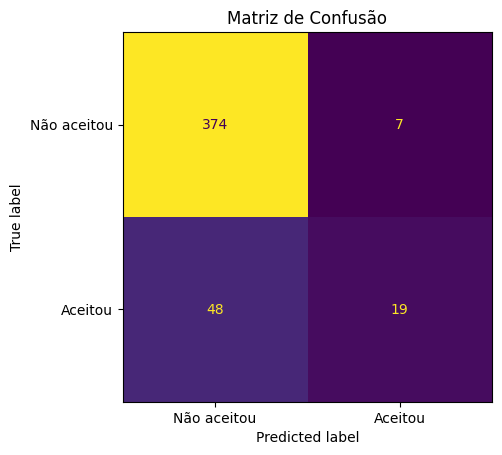

In [197]:
# A matriz de confusão mostra onde o modelo acertou e onde errou
ConfusionMatrixDisplay.from_predictions(
    y_teste, y_previsto,
    display_labels=['Não aceitou', 'Aceitou'],
    colorbar=False
)
plt.title('Matriz de Confusão')
plt.show()

#Calcular o ROC-AUC

In [188]:
# ROC-AUC mede a capacidade geral do modelo de separar as duas classes
# Vai de 0.5 (chute aleatório) até 1.0 (perfeito)
y_prob = modelo.predict_proba(X_teste)[:, 1]
auc = roc_auc_score(y_teste, y_prob)

print(f'ROC-AUC: {auc:.4f}')

ROC-AUC: 0.8515


#Identificar as features mais importantes

In [189]:
# O Random Forest registra o quanto cada feature ajudou nas decisões
importancias = pd.Series(
    modelo.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print('Top 10 features mais importantes:')
print(importancias.head(10).round(4))

Top 10 features mais importantes:
Recency                0.1028
TotalSpend             0.0806
MntGoldProds           0.0631
Income                 0.0619
MntMeatProducts        0.0603
MntWines               0.0562
Year_Customer          0.0457
NumCatalogPurchases    0.0440
AcceptedCmp3           0.0432
NumStorePurchases      0.0396
dtype: float64


#Gráfico das top 10 features

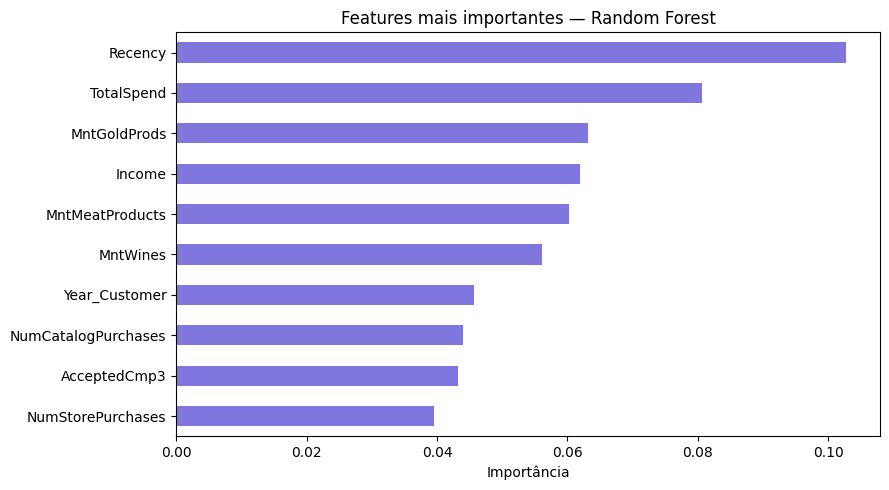

In [190]:
importancias.head(10).plot(
    kind='barh',
    figsize=(9, 5),
    color='#7F77DD'
)

plt.xlabel('Importância')
plt.title('Features mais importantes — Random Forest')
plt.gca().invert_yaxis()  # coloca a mais importante no topo
plt.tight_layout()
plt.show()

#Salvar resultados

In [191]:
# Salvei em CSV para usar na comparação final
importancias.reset_index().rename(
    columns={'index': 'feature', 0: 'importancia'}
).to_csv('importancias_modelo.csv', index=False)

print('Salvo: importancias_modelo.csv')

Salvo: importancias_modelo.csv


#Comparação entre os metodos

In [192]:
# Resultados do Teste Z (Parte 1)
df_z = pd.read_csv('resultados_teste_z.csv')

# Importâncias do modelo Random Forest (Parte 2)
df_imp = pd.read_csv('importancias_modelo.csv')

print('Arquivos carregados!')

Arquivos carregados!


In [193]:
# Filtramos só as significativas e pegamos as 5 com menor p-value
top5_z = (df_z[df_z['significativa'] == True]
          .sort_values('p_value')
          .head(5)['feature']
          .tolist())

print('Top 5 — Teste Z:')
for i, f in enumerate(top5_z, 1):
    print(f'  {i}. {f}')

Top 5 — Teste Z:
  1. Income
  2. Teenhome
  3. MntWines
  4. Recency
  5. MntFruits


In [194]:
# Pegamos as 5 com maior importância no Random Forest
top5_ml = (df_imp
           .sort_values('importancia', ascending=False)
           .head(5)['feature']
           .tolist())

print('Top 5 — Random Forest:')
for i, f in enumerate(top5_ml, 1):
    print(f'  {i}. {f}')

Top 5 — Random Forest:
  1. Recency
  2. TotalSpend
  3. MntGoldProds
  4. Income
  5. MntMeatProducts


#Tabela comparativa

In [195]:
# Criamos uma tabela com os dois rankings lado a lado
# e marcamos quais features aparecem nos dois
df_comparacao = pd.DataFrame({
    'posicao'   : [1, 2, 3, 4, 5],
    'teste_z'   : top5_z,
    'random_forest' : top5_ml
})

# Coluna que indica se a feature aparece nos dois métodos
df_comparacao['em_ambos'] = df_comparacao.apply(
    lambda row: 'Sim' if row['teste_z'] in top5_ml
                      or row['random_forest'] in top5_z
                else 'Não',
    axis=1
)

print(df_comparacao.to_string(index=False))

 posicao   teste_z   random_forest em_ambos
       1    Income         Recency      Sim
       2  Teenhome      TotalSpend      Não
       3  MntWines    MntGoldProds      Não
       4   Recency          Income      Sim
       5 MntFruits MntMeatProducts      Não


# Visualizar a comparação

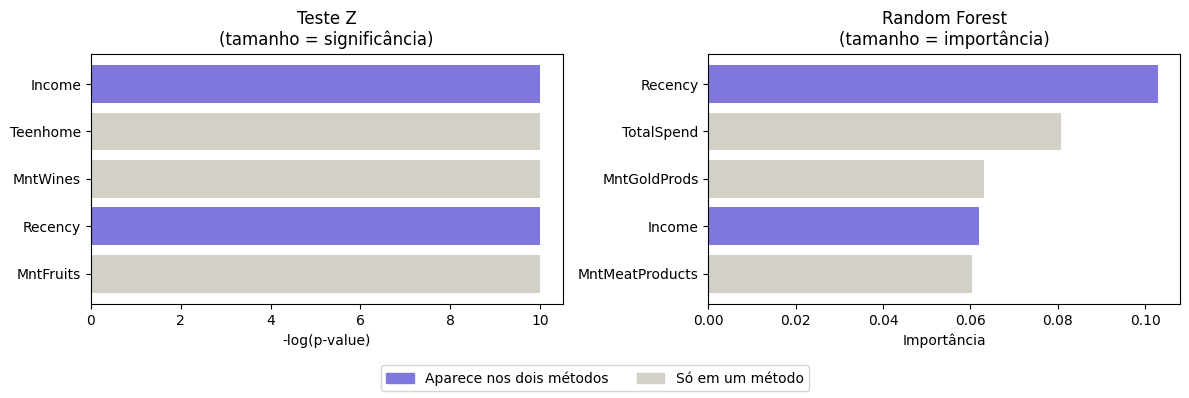

In [196]:
import matplotlib.patches as mpatches
import numpy as np

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Cores: roxo = aparece em ambos, cinza = só em um método
cores_z  = ['#7F77DD' if f in top5_ml else '#D3D1C7' for f in top5_z]
cores_ml = ['#7F77DD' if f in top5_z  else '#D3D1C7' for f in top5_ml]

# Gráfico do Teste Z (usamos -log do p-value: quanto maior a barra, mais significativo)
pvalores = [df_z[df_z['feature']==f]['p_value'].values[0] for f in top5_z]
ax1.barh(top5_z[::-1], [-np.log10(p+1e-10) for p in pvalores[::-1]], color=cores_z[::-1])
ax1.set_title('Teste Z\n(tamanho = significância)')
ax1.set_xlabel('-log(p-value)')

# Gráfico do Random Forest
imp_vals = [df_imp[df_imp['feature']==f]['importancia'].values[0] for f in top5_ml]
ax2.barh(top5_ml[::-1], imp_vals[::-1], color=cores_ml[::-1])
ax2.set_title('Random Forest\n(tamanho = importância)')
ax2.set_xlabel('Importância')

legenda = [
    mpatches.Patch(color='#7F77DD', label='Aparece nos dois métodos'),
    mpatches.Patch(color='#D3D1C7', label='Só em um método')
]
fig.legend(handles=legenda, loc='lower center', ncol=2, fontsize=10)
plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.show()

#Conslusão

Com base no desenvolvimento do projeto, concluo que a integração entre a análise estatística clássica e as técnicas de Machine Learning oferece uma visão completa e robusta sobre o comportamento dos clientes da plataforma. Através do Teste Z, foi possível validar cientificamente que variáveis como a renda (Income) e o volume de gastos em categorias específicas, como vinhos (MntWines), não possuem médias iguais entre os grupos, comprovando que os clientes que aceitam campanhas possuem, de fato, um perfil financeiro e de consumo distinto.

Essa evidência estatística serviu como alicerce para a construção do modelo de Random Forest, que não apenas confirmou a relevância dessas variáveis, mas também as organizou por ordem de importância preditiva, destacando fatores como o gasto total (TotalSpend) e a recência (Recency) como pilares para a tomada de decisão do algoritmo. O equilíbrio alcançado pelo modelo, evidenciado pelo uso de pesos para classes desbalanceadas e pela métrica ROC-AUC, demonstra que é possível transformar dados históricos em uma ferramenta prática de previsão de mercado.

Portanto, a convergência dos dois métodos revela que, enquanto a estatística nos dá a segurança de que as diferenças observadas não são fruto do acaso, o Machine Learning utiliza essa estrutura para gerar valor preditivo. Para o negócio, isso significa que as estratégias de marketing podem ser direcionadas com maior precisão, focando em clientes com características que comprovadamente aumentam as chances de conversão, otimizando recursos e potencializando os resultados das campanhas.